In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Chargement du fichier consolidé
df_ml = pd.read_csv("Base_Finale_ML_1401_Clean.csv", sep=';', encoding='utf-8-sig')

# 2. Nettoyage des colonnes textuelles (Encodage)
le = LabelEncoder()
# On sélectionne les colonnes catégorielles (on exclut les numériques et les dates)
cat_cols = ['Type_versement', 'Frequence', 'Ville', 'Agence', 'Beneficiaires']

for col in cat_cols:
    if col in df_ml.columns:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str).fillna('Inconnu'))

# 3. Séparation Features (X) et Cible (y)
# On retire ID_Police (identifiant unique) et les colonnes de dates brutes si elles existent encore
X = df_ml.drop(columns=['ID_Police', 'Rachat'], errors='ignore')
y = df_ml['Rachat']

# 4. Split 80% Train / 20% Test (avec stratification pour garder le même % de rachats dans les deux)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"✅ Fichier chargé et encodé !")
print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
print(f"Taux de rachat réel : {y.mean():.2%}")

✅ Fichier chargé et encodé !
Taille du jeu d'entraînement : 98202 lignes
Taux de rachat réel : 42.77%


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Chargement
df_ml = pd.read_csv("Base_Finale_ML_1401_Clean.csv", sep=';', encoding='utf-8-sig')

# 2. On supprime les colonnes de texte "brut" (Dates et ID) qui ne servent plus au calcul
# car nous avons déjà extrait l'Age, l'Anciennete et l'Annee_Effet
cols_a_supprimer = ['ID_Police', 'Date_Naissance', 'Debut', 'Fin', 'ï»¿ID_Police']
df_ml = df_ml.drop(columns=[c for c in cols_a_supprimer if c in df_ml.columns])

# 3. Encodage des colonnes catégorielles
le = LabelEncoder()
cat_cols = ['Type_versement', 'Frequence', 'Ville', 'Agence', 'Beneficiaires']

for col in cat_cols:
    if col in df_ml.columns:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str).fillna('Inconnu'))

# 4. Séparation X et y
X = df_ml.drop(columns=['Rachat'])
y = df_ml['Rachat']

# 5. Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("✅ Données nettoyées et prêtes pour le ML.")
print(f"Colonnes utilisées pour l'apprentissage : {list(X.columns)}")

✅ Données nettoyées et prêtes pour le ML.
Colonnes utilisées pour l'apprentissage : ['Montant_Initial_Versement', 'Montant_Regulier', 'Type_versement', 'Frequence', 'TMP_ANNUITY_TERM', 'Ville', 'Code_Postal', 'Beneficiaires', 'Agence', 'Age', 'Anciennete', 'Annee_Effet', 'Charge_Finale']


C:\Users\ROG\AppData\Local\Temp\ipykernel_22284\1404520474.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


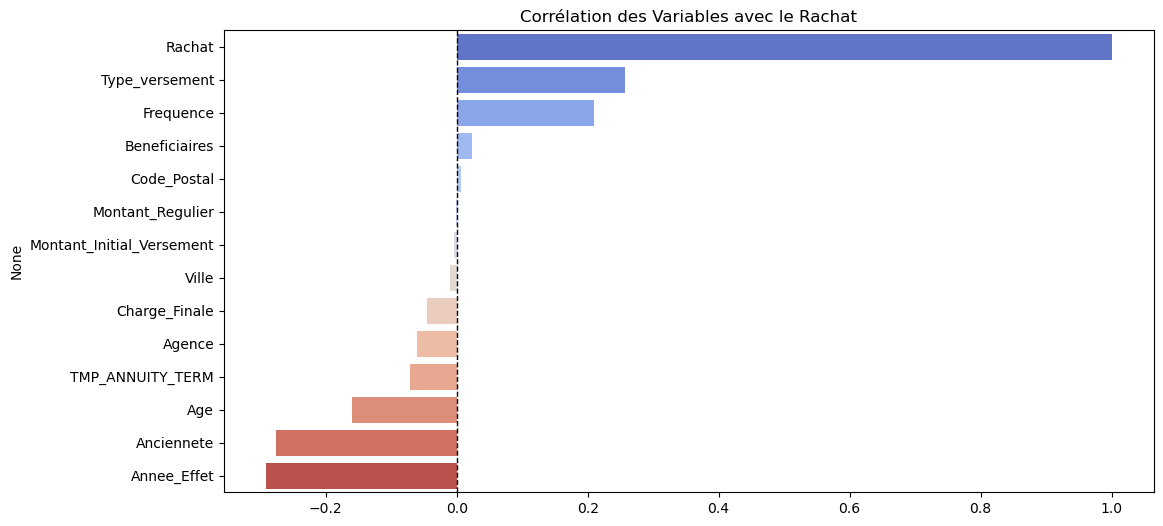

--- Top Corrélations ---
Rachat                       1.000000
Type_versement               0.256295
Frequence                    0.209432
Beneficiaires                0.023000
Code_Postal                  0.006319
Montant_Regulier            -0.000725
Montant_Initial_Versement   -0.003574
Ville                       -0.010731
Charge_Finale               -0.045626
Agence                      -0.059895
TMP_ANNUITY_TERM            -0.071264
Age                         -0.159961
Anciennete                  -0.276254
Annee_Effet                 -0.290953
Name: Rachat, dtype: float64


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# On force le calcul uniquement sur les colonnes numériques
correlations = df_ml.corr(numeric_only=True)['Rachat'].sort_values(ascending=False)

sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Corrélation des Variables avec le Rachat')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()

print("--- Top Corrélations ---")
print(correlations)

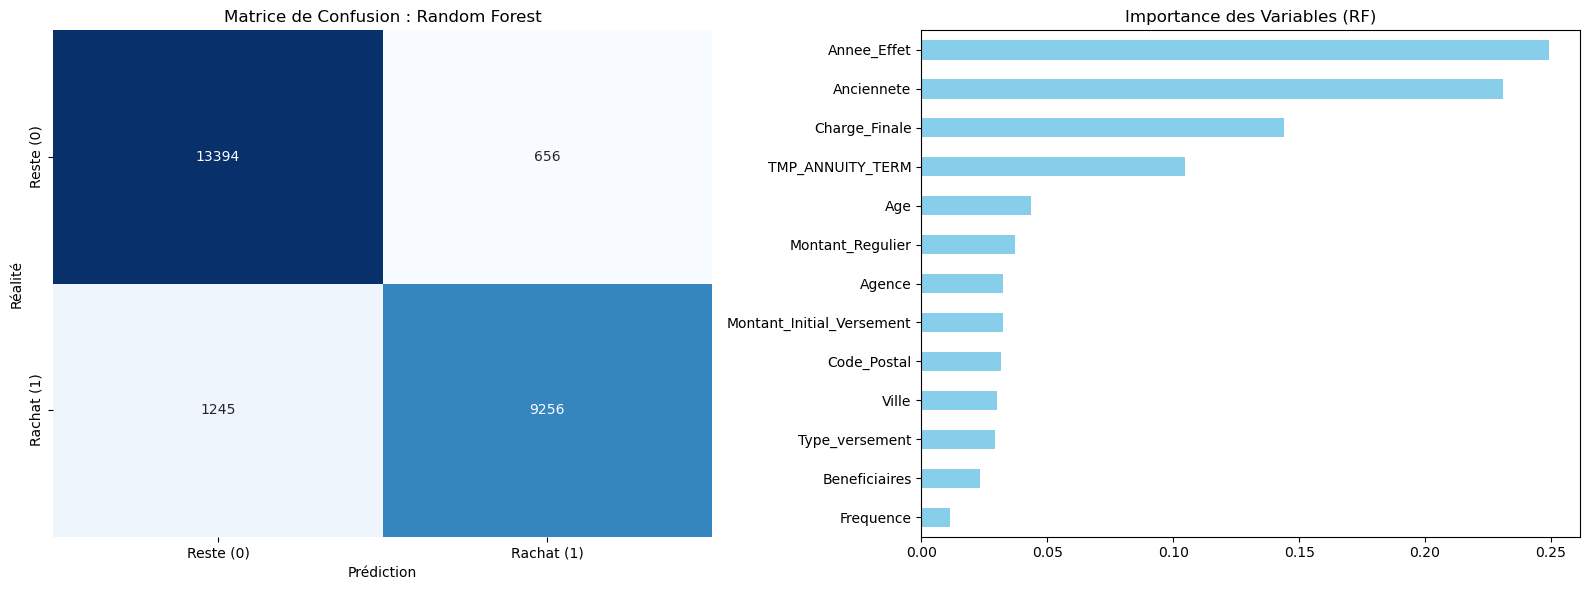

Accuracy RF: 92.26%


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Entraînement
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 2. Création de la figure (2 colonnes : Matrice et Importance)
plt.figure(figsize=(16, 6))

# Sous-graphe 1 : Matrice de Confusion
plt.subplot(1, 2, 1)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Reste (0)', 'Rachat (1)'], 
            yticklabels=['Reste (0)', 'Rachat (1)'])
plt.title('Matrice de Confusion : Random Forest')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')

# Sous-graphe 2 : Importance des variables
plt.subplot(1, 2, 2)
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', color='skyblue')
plt.title('Importance des Variables (RF)')

plt.tight_layout()
plt.show()

print(f"Accuracy RF: {accuracy_score(y_test, y_pred_rf):.2%}")

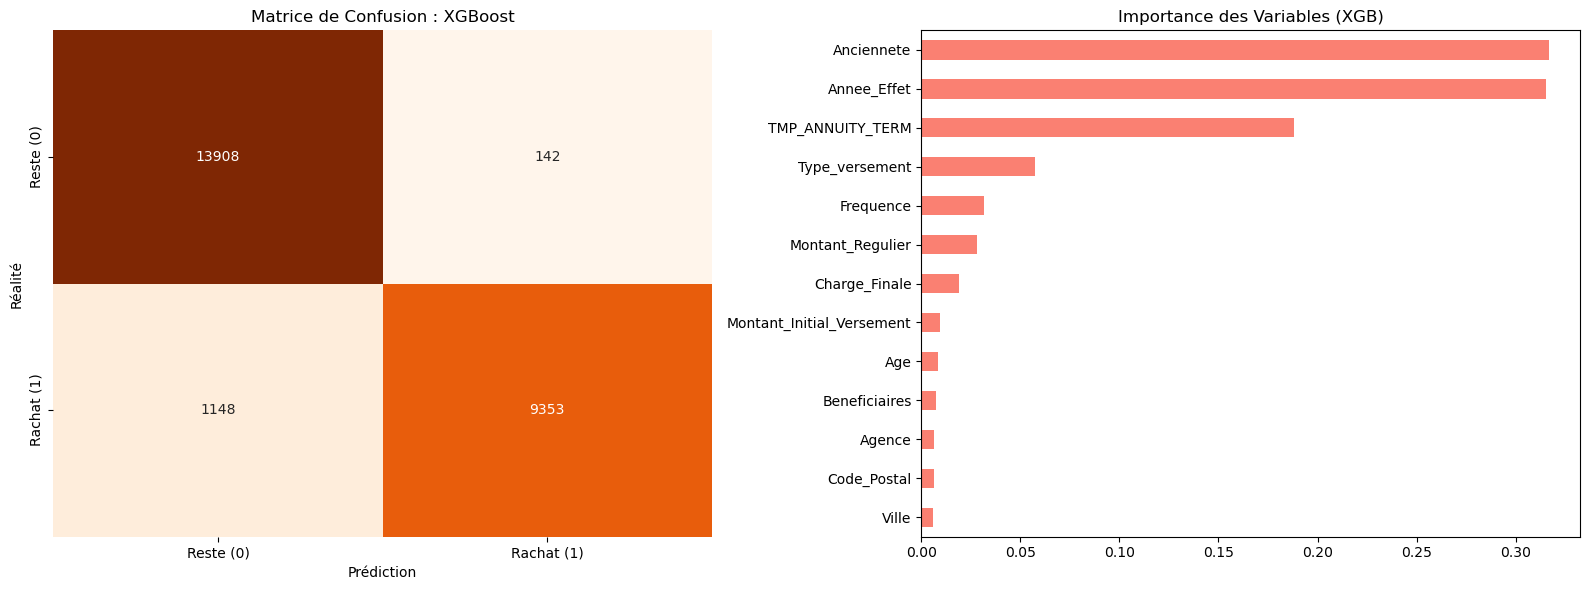

Accuracy XGB: 94.75%


In [15]:
from xgboost import XGBClassifier

# 1. Entraînement
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 2. Création de la figure
plt.figure(figsize=(16, 6))

# Sous-graphe 1 : Matrice de Confusion
plt.subplot(1, 2, 1)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Reste (0)', 'Rachat (1)'], 
            yticklabels=['Reste (0)', 'Rachat (1)'])
plt.title('Matrice de Confusion : XGBoost')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')

# Sous-graphe 2 : Importance des variables
plt.subplot(1, 2, 2)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
xgb_importances.plot(kind='barh', color='salmon')
plt.title('Importance des Variables (XGB)')

plt.tight_layout()
plt.show()

print(f"Accuracy XGB: {accuracy_score(y_test, y_pred_xgb):.2%}")

# test à variables réduites